# Exploratory Data Analysis on Australian Weather Dataset

## Project Objective
The goal of this project is to explore historical weather data from Australia,
analyze rainfall patterns, and identify key weather factors associated with rain occurrence.

This analysis focuses on:
- Data cleaning and preprocessing
- Exploratory Data Analysis (EDA)
- Identifying correlations between weather variables
- Understanding rainfall trends over time and locations


## Dataset Description
- Source: Australian Bureau of Meteorology (WeatherAUS dataset)
- Total Records: 145,460
- Total Features (initial): 23
- Target Variable: RainTomorrow (Yes/No)

The dataset contains daily weather observations including temperature, humidity,
pressure, and rainfall across multiple Australian locations.


In [24]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [25]:
df = pd.read_csv("weatherAUS.csv" , encoding= "ISO-8859-1")
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


## Initial Data Inspection
We inspect the structure, data types, missing values, and duplicates in the dataset.


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

In [27]:
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,143975.000000,144199.000000,142199.000000,82670.000000,75625.000000,135197.000000,143693.000000,142398.000000,142806.000000,140953.000000,130395.00000,130432.000000,89572.000000,86102.000000,143693.000000,141851.00000
mean,12.194034,23.221348,2.360918,5.468232,7.611178,40.035230,14.043426,18.662657,68.880831,51.539116,1017.64994,1015.255889,4.447461,4.509930,16.990631,21.68339
std,6.398495,7.119049,8.478060,4.193704,3.785483,13.607062,8.915375,8.809800,19.029164,20.795902,7.10653,7.037414,2.887159,2.720357,6.488753,6.93665
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.50000,977.100000,0.000000,0.000000,-7.200000,-5.40000
25%,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.90000,1010.400000,1.000000,2.000000,12.300000,16.60000
50%,12.000000,22.600000,0.000000,4.800000,8.400000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.60000,1015.200000,5.000000,5.000000,16.700000,21.10000
75%,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.40000,1020.000000,7.000000,7.000000,21.600000,26.40000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.00000,1039.600000,9.000000,9.000000,40.200000,46.70000


In [28]:
df.isna().sum()

,0
Date,0
Location,0
MinTemp,1485
MaxTemp,1261
Rainfall,3261
Evaporation,62790
Sunshine,69835
WindGustDir,10326
WindGustSpeed,10263
WindDir9am,10566


In [29]:
df.duplicated().sum()

np.int64(0)

In [30]:
Columns_to_keep = ["Date","Location","MinTemp","MaxTemp","Rainfall","Humidity9am","Humidity3pm",
                   "Pressure9am","Pressure3pm","Temp9am","Temp3pm","RainToday","RainTomorrow"]

df = df.loc[:,Columns_to_keep].copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Date          145460 non-null  object 
 1   Location      145460 non-null  object 
 2   MinTemp       143975 non-null  float64
 3   MaxTemp       144199 non-null  float64
 4   Rainfall      142199 non-null  float64
 5   Humidity9am   142806 non-null  float64
 6   Humidity3pm   140953 non-null  float64
 7   Pressure9am   130395 non-null  float64
 8   Pressure3pm   130432 non-null  float64
 9   Temp9am       143693 non-null  float64
 10  Temp3pm       141851 non-null  float64
 11  RainToday     142199 non-null  object 
 12  RainTomorrow  142193 non-null  object 
dtypes: float64(9), object(4)
memory usage: 14.4+ MB


## Feature Selection
Relevant features were selected based on their importance in weather and rainfall analysis.
Unnecessary or highly missing columns were removed to simplify analysis.


In [31]:
df["Date"] = pd.to_datetime(df["Date"])

In [32]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month

In [33]:
df[["Date","Year","Month"]].head()

,Date,Year,Month
0,2008-12-01,2008,12
1,2008-12-02,2008,12
2,2008-12-03,2008,12
3,2008-12-04,2008,12
4,2008-12-05,2008,12


## Date Feature Engineering
The Date column was converted into datetime format, and additional features such as
Year and Month were extracted to analyze time-based trends.


In [34]:
df.isna().sum()

,0
Date,0
Location,0
MinTemp,1485
MaxTemp,1261
Rainfall,3261
Humidity9am,2654
Humidity3pm,4507
Pressure9am,15065
Pressure3pm,15028
Temp9am,1767


###Data Cleaning and Preparation

In [35]:
num_cols = ["MinTemp","MaxTemp","Rainfall","Humidity3pm","Humidity9am","Pressure9am","Pressure3pm",
            "Temp9am","Temp3pm"]

for col in num_cols:
  df[col].fillna(df[col].median(), inplace=True)

/tmp/ipython-input-3263757880.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [36]:
df.isna().sum()

,0
Date,0
Location,0
MinTemp,0
MaxTemp,0
Rainfall,0
Humidity9am,0
Humidity3pm,0
Pressure9am,0
Pressure3pm,0
Temp9am,0


In [37]:
df["RainToday"].isna().sum()

np.int64(3261)

In [38]:
df["RainToday"] = df["RainToday"].fillna(df["RainToday"].mode()[0])

In [39]:
df["RainTomorrow"] = df["RainTomorrow"].fillna(df["RainTomorrow"].mode()[0])

In [40]:
df["RainToday"].isna().sum()

np.int64(0)

In [41]:
df["RainToday"].unique()

array(['No', 'Yes'], dtype=object)

In [42]:
df["RainToday"] = df["RainToday"].map({"Yes" : 1, "No":0})

In [43]:
df["RainToday"]

,RainToday
0,0
1,0
2,0
3,0
4,0
...,...
145455,0
145456,0
145457,0
145458,0


In [44]:
df["RainTomorrow"] = df["RainTomorrow"].map({"Yes":1, "No": 0})

## Data Cleaning and Missing Value Treatment
- Numerical columns were filled using median values to handle skewness.
- Categorical variables were filled using mode.
- Binary encoding was applied to RainToday and RainTomorrow.


In [45]:
df.isna().sum()

,0
Date,0
Location,0
MinTemp,0
MaxTemp,0
Rainfall,0
Humidity9am,0
Humidity3pm,0
Pressure9am,0
Pressure3pm,0
Temp9am,0


## Final Dataset Summary
After cleaning and preprocessing, the dataset is ready for exploratory analysis.


In [46]:
df.shape

(145460, 15)

## Exploratory Data Analysis (EDA)

In [47]:
df.describe()

,Date,MinTemp,MaxTemp,Rainfall,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Year,Month
count,145460,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000
mean,2013-04-04 21:08:51.907053568,12.192053,23.215962,2.307990,68.901251,51.553396,1017.644768,1015.250115,16.987101,21.668916,0.219167,0.219146,2012.769751,6.399615
min,2007-11-01 00:00:00,-8.500000,-4.800000,0.000000,0.000000,0.000000,980.500000,977.100000,-7.200000,-5.400000,0.000000,0.000000,2007.000000,1.000000
25%,2011-01-11 00:00:00,7.700000,18.000000,0.000000,57.000000,37.000000,1013.500000,1011.100000,12.300000,16.700000,0.000000,0.000000,2011.000000,3.000000
50%,2013-06-02 00:00:00,12.000000,22.600000,0.000000,70.000000,52.000000,1017.600000,1015.200000,16.700000,21.100000,0.000000,0.000000,2013.000000,6.000000
75%,2015-06-14 00:00:00,16.800000,28.200000,0.600000,83.000000,65.000000,1021.800000,1019.400000,21.500000,26.200000,0.000000,0.000000,2015.000000,9.000000
max,2017-06-25 00:00:00,33.900000,48.100000,371.000000,100.000000,100.000000,1041.000000,1039.600000,40.200000,46.700000,1.000000,1.000000,2017.000000,12.000000
std,NaN,6.365780,7.088358,8.389771,18.855360,20.471345,6.728484,6.663994,6.449299,6.850658,0.413683,0.413669,2.537684,3.427262


## RainTomorrow Distribution
This section analyzes the balance of the target variable to understand
whether rainfall occurrence is imbalanced.


In [48]:
df["RainTomorrow"].value_counts()

,count
RainTomorrow,
0,113583
1,31877


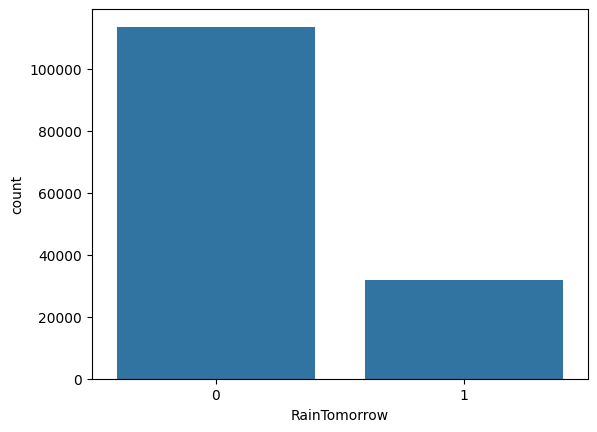

In [49]:
sns.countplot(data = df, x= "RainTomorrow")
plt.show()

## Rainfall vs RainTomorrow


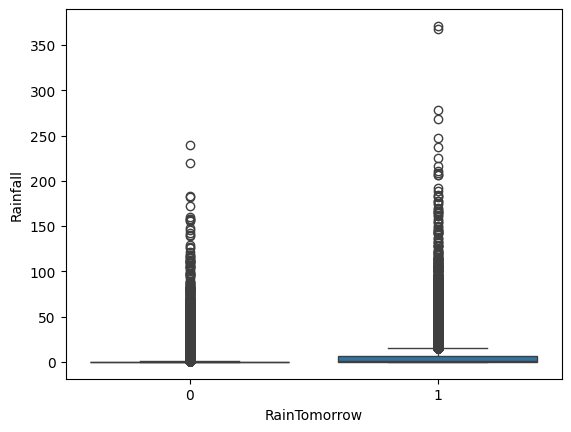

In [50]:
sns.boxplot(data=df , x="RainTomorrow" , y="Rainfall")
plt.show()

- Higher rainfall values are strongly associated with RainTomorrow = Yes.
- Rainfall is a key predictive feature for future rain.


## Humidity and Temperature Analysis


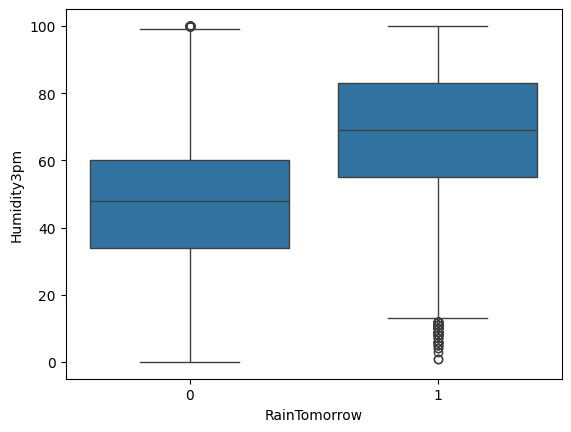

In [51]:
sns.boxplot(data =df, x= "RainTomorrow", y="Humidity3pm")
plt.show()

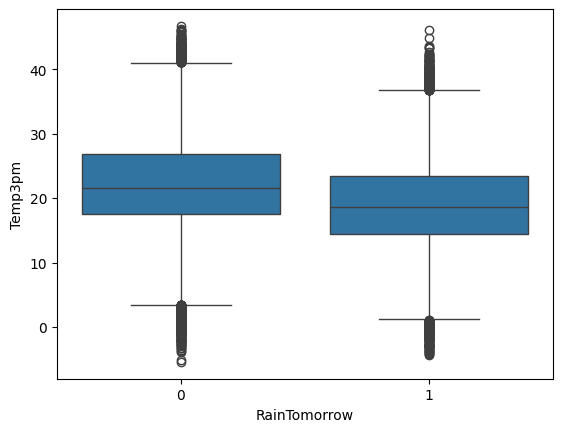

In [52]:
sns.boxplot(data = df, x= "RainTomorrow", y= "Temp3pm")
plt.show()

- Higher afternoon humidity (Humidity3pm) significantly increases the likelihood of rain.
- Lower afternoon temperatures are generally associated with rainy days.


## Correlation Analysis
A heatmap is used to visualize relationships between numerical variables.


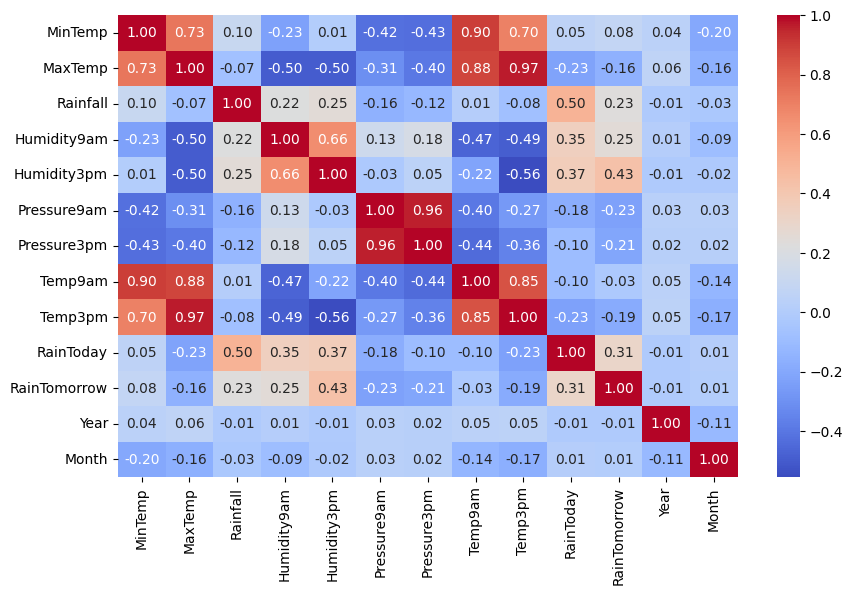

In [53]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.show()


- Humidity shows a strong positive correlation with rainfall.
- Pressure variables are negatively correlated with rainfall.
- Temperature features are moderately correlated with each other.


## Rainfall Trends Over Time


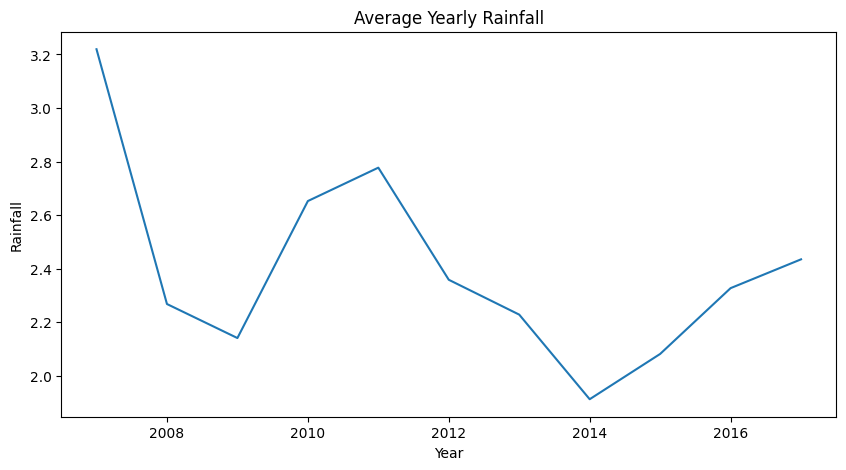

In [54]:
yearly_rain = df.groupby("Year")["Rainfall"].mean()

plt.figure(figsize=(10,5))
yearly_rain.plot()
plt.title("Average Yearly Rainfall")
plt.xlabel("Year")
plt.ylabel("Rainfall")
plt.show()


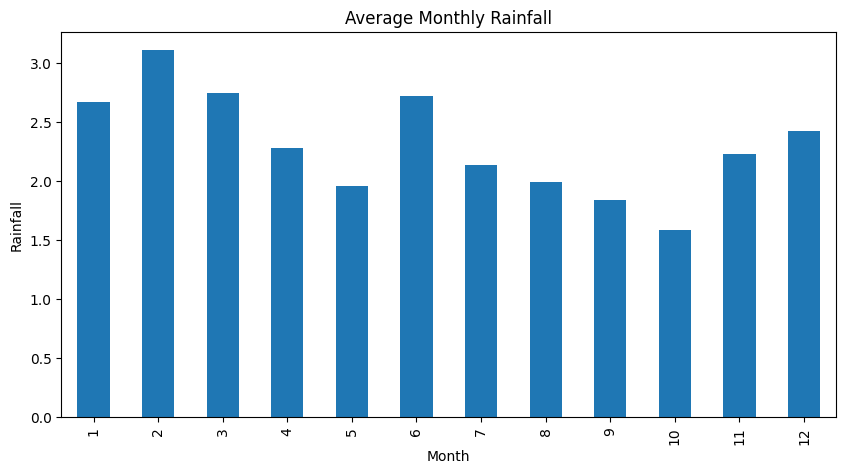

In [55]:
monthly_rain = df.groupby("Month")["Rainfall"].mean()

plt.figure(figsize=(10,5))
monthly_rain.plot(kind="bar")
plt.title("Average Monthly Rainfall")
plt.xlabel("Month")
plt.ylabel("Rainfall")
plt.show()


- Rainfall patterns vary across years, showing seasonal and climatic fluctuations.
- Certain months consistently experience higher rainfall, indicating seasonal trends.


## Rainfall by Location


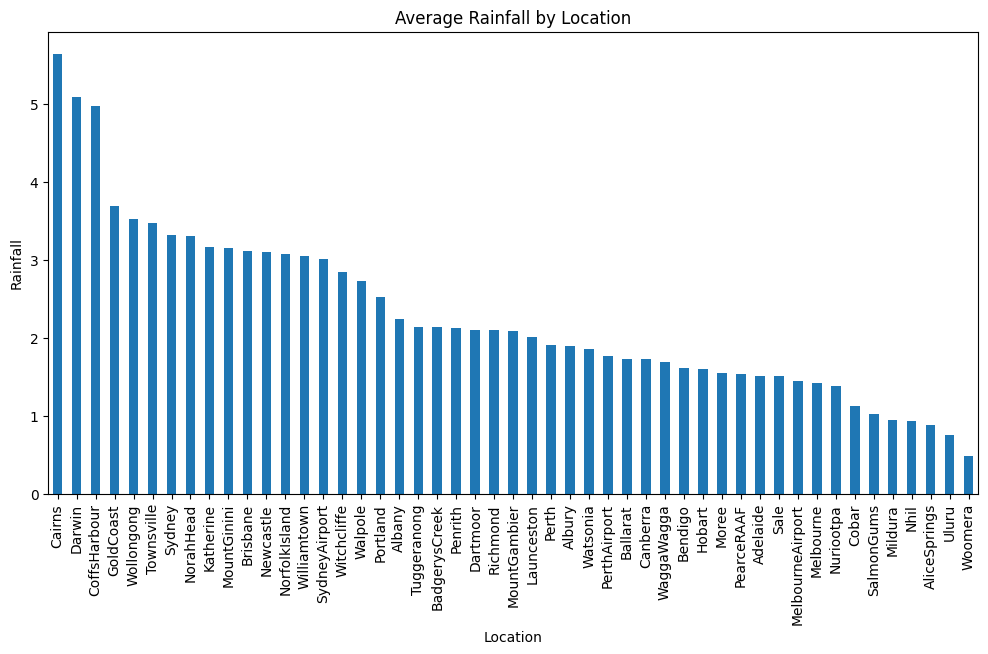

In [56]:
location_rain = df.groupby("Location")["Rainfall"].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
location_rain.plot(kind="bar")
plt.title("Average Rainfall by Location")
plt.xlabel("Location")
plt.ylabel("Rainfall")
plt.show()


- Coastal locations generally experience higher average rainfall.
- Inland locations tend to be drier with lower rainfall averages.
